# Sleep, Doomscrolling & Digital Wellbeing

### A reproducible portfolio analysis of 1,000 respondents

This notebook investigates how bedtime screen habits and doomscrolling **relate to** sleep duration, sleep latency, weekly sleep debt, stress, and daytime fatigue. It combines data-quality auditing, exploratory analysis, visualization, cohort comparison, and an interpretable machine-learning baseline.

> **Portfolio note:** The analysis is observational. Results describe associations and must not be interpreted as evidence that doomscrolling causes sleep outcomes.


## tl;dr

- The dataset contains **1,000 unique respondents**, 30 fields, and no duplicate records.
- **47.6%** of respondents are labelled doomscrollers.
- Doomscrollers average **33.4 minutes of sleep latency**, compared with **22.9 minutes** for non-doomscrollers—a **10.6-minute gap**.
- They also average **0.24 fewer sleep hours** and **1.49 more hours of weekly sleep debt**.
- Bedtime screen time has a **-0.44 correlation** with nightly sleep duration; this is the strongest non-derived negative relationship examined.
- A leakage-controlled random-forest model predicts sleep-quality category at **58.0% accuracy**, above the **34.0% majority-class baseline**. The result is useful as a predictive benchmark, not a clinical model.


## Context & Methods

### Analytical question

How do doomscrolling and bedtime digital habits differ across sleep and wellbeing outcomes, and how much signal do these features contain for predicting sleep-quality category?

### Method

1. Audit shape, uniqueness, missingness, ranges, and category balance.
2. Compare doomscroller and non-doomscroller cohorts using counts and means.
3. Compare poor, fair, and good sleep-quality groups.
4. Examine correlations and the screen-time/sleep relationship.
5. Train a held-out random-forest benchmark with preprocessing inside a pipeline.

### Key assumptions

- One row represents one respondent; `respondent_id` is expected to be unique.
- Missing numeric values are median-imputed and missing categorical values use the most frequent category **inside the model pipeline**.
- `sleep_quality_score`, `weekly_sleep_debt_hours`, and `doomscroller` are excluded from the model to reduce direct target leakage or label-derived shortcuts.
- The supplied archive does not include collection methodology, sampling design, survey date, or a data dictionary. Findings may not generalize beyond this sample.


## Data

Source file: `data/sleep_doomscrolling_habits.csv`  
Original supplied archive: `archive (7).zip`

The repository keeps the raw CSV unchanged so every transformation below can be rerun and audited.


In [1]:
# 1. Imports and display settings
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

BLUE = "#2F6BFF"
GOLD = "#E7A83E"
INK = "#20242B"
GREY = "#6B7280"
LIGHT_GREY = "#E5E7EB"
PALE_BLUE = "#DCE7FF"

plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.edgecolor": LIGHT_GREY,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "font.size": 10,
    "text.color": INK,
    "xtick.color": GREY,
    "ytick.color": GREY,
    "grid.color": LIGHT_GREY,
    "grid.linewidth": 0.8,
})

RANDOM_STATE = 42
DATA_PATH = Path("data/sleep_doomscrolling_habits.csv")


In [2]:
# 2. Load the data
df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
display(df.head(5))


Rows: 1,000
Columns: 30


,respondent_id,age,bedtime_screen_time_minutes,total_daily_screen_time_hours,doomscroll_sessions_per_night,avg_doomscroll_session_minutes,sleep_hours_per_night,sleep_latency_minutes,number_of_night_wakeups,caffeine_intake_mg_per_day,anxiety_score,stress_score,sleep_quality_score,daytime_fatigue_score,number_of_news_apps_used,phone_checks_per_night,exercise_minutes_per_day,days_since_last_digital_detox,weekly_sleep_debt_hours,gender,occupation_status,country_region,primary_device_used_at_night,bedtime_routine_type,uses_night_mode,keeps_phone_in_bedroom,consumes_negative_news_content,uses_sleep_tracking_app,doomscroller,sleep_quality_category
0,D30000,22,13.00,1.85,2,5.40,8.10,19.00,2,155.00,5,7,5.00,6,3,3,103.00,9.00,0.70,Male,Unemployed,Germany,Tablet,Meditation/Journaling,Yes,Yes,Yes,No,Yes,Good
1,D30001,18,90.00,3.61,3,29.60,7.00,31.00,3,82.00,5,6,3.00,9,2,3,28.00,24.00,7.50,Male,Student,India,Smartphone,Meditation/Journaling,No,Yes,Yes,No,Yes,Poor
2,D30002,37,51.00,5.15,3,15.50,7.10,24.00,2,49.00,2,2,5.00,8,0,3,11.00,15.00,2.90,Prefer not to say,Student,India,Laptop,Reading,No,Yes,No,Yes,Yes,Fair
3,D30003,27,53.00,3.74,0,51.40,8.40,35.00,0,42.00,6,6,5.00,4,1,0,61.00,13.00,0.00,Prefer not to say,NaN,United States,Smartphone,No Fixed Routine,No,Yes,Yes,No,No,Fair
4,D30004,17,67.00,6.09,2,32.20,7.20,19.00,1,76.00,5,7,5.00,7,3,3,23.00,19.00,5.40,Prefer not to say,Employed Part-time,United States,Smartphone,Watching Videos,No,No,No,No,No,Fair


### Data-quality audit

The checks below establish the analysis grain and surface missingness before any modelling. Missing values are retained for descriptive summaries and handled inside the model pipeline to avoid train/test leakage.


In [3]:
# 3. Validate uniqueness, missingness, and category balance
quality_checks = pd.DataFrame({
    "check": ["Rows", "Columns", "Duplicate rows", "Duplicate respondent IDs"],
    "value": [len(df), df.shape[1], int(df.duplicated().sum()), int(df["respondent_id"].duplicated().sum())],
})

missing = (
    df.isna().sum()
    .loc[lambda values: values.gt(0)]
    .sort_values(ascending=False)
    .rename("missing_rows")
    .to_frame()
)
missing["missing_pct"] = missing["missing_rows"].div(len(df)).mul(100)

display(quality_checks)
display(missing)


,check,value
0,Rows,1000
1,Columns,30
2,Duplicate rows,0
3,Duplicate respondent IDs,0


,missing_rows,missing_pct
caffeine_intake_mg_per_day,50,5.00
exercise_minutes_per_day,50,5.00
sleep_quality_score,40,4.00
occupation_status,30,3.00
primary_device_used_at_night,30,3.00
bedtime_routine_type,20,2.00


In [4]:
# 4. Inspect numeric ranges for plausibility
key_numeric = [
    "age", "bedtime_screen_time_minutes", "total_daily_screen_time_hours",
    "sleep_hours_per_night", "sleep_latency_minutes", "weekly_sleep_debt_hours",
    "stress_score", "daytime_fatigue_score", "exercise_minutes_per_day",
]

range_summary = df[key_numeric].describe(percentiles=[0.05, 0.5, 0.95]).T[
    ["count", "mean", "std", "min", "5%", "50%", "95%", "max"]
]
display(range_summary)


,count,mean,std,min,5%,50%,95%,max
age,"1,000.00",27.31,7.50,15.00,15.00,27.00,40.00,54.00
bedtime_screen_time_minutes,"1,000.00",50.11,31.33,1.00,13.00,44.00,108.00,225.00
total_daily_screen_time_hours,"1,000.00",3.66,1.92,1.00,1.18,3.34,7.17,12.95
sleep_hours_per_night,"1,000.00",7.42,0.77,4.00,6.10,7.40,8.70,9.80
sleep_latency_minutes,"1,000.00",27.88,14.51,2.00,6.00,27.00,53.05,90.00
weekly_sleep_debt_hours,"1,000.00",4.86,4.65,0.00,0.00,3.90,13.50,29.40
stress_score,"1,000.00",6.15,1.89,1.00,3.00,6.00,9.00,10.00
daytime_fatigue_score,"1,000.00",5.98,1.76,1.00,3.00,6.00,9.00,10.00
exercise_minutes_per_day,950.00,53.28,21.16,0.00,17.45,54.00,87.00,124.00


## Results

### 1. Doomscrolling cohorts show meaningful sleep gaps

The cohort table provides exact lookup values, while the chart focuses on the three sleep outcomes most relevant to the comparison. Group sizes are shown to keep the denominator visible.


In [5]:
# 5. Compare doomscroller cohorts
doom_summary = (
    df.groupby("doomscroller", observed=True)
    .agg(
        respondents=("respondent_id", "count"),
        sleep_hours=("sleep_hours_per_night", "mean"),
        sleep_latency_minutes=("sleep_latency_minutes", "mean"),
        weekly_sleep_debt_hours=("weekly_sleep_debt_hours", "mean"),
        bedtime_screen_minutes=("bedtime_screen_time_minutes", "mean"),
        stress_score=("stress_score", "mean"),
        daytime_fatigue=("daytime_fatigue_score", "mean"),
    )
    .reindex(["No", "Yes"])
)
display(doom_summary.round(2))

cohort_share = df["doomscroller"].eq("Yes").mean()
latency_gap = doom_summary.loc["Yes", "sleep_latency_minutes"] - doom_summary.loc["No", "sleep_latency_minutes"]
sleep_gap = doom_summary.loc["Yes", "sleep_hours"] - doom_summary.loc["No", "sleep_hours"]
debt_gap = doom_summary.loc["Yes", "weekly_sleep_debt_hours"] - doom_summary.loc["No", "weekly_sleep_debt_hours"]

print(f"Doomscroller share: {cohort_share:.1%}")
print(f"Sleep latency gap: {latency_gap:+.2f} minutes")
print(f"Nightly sleep gap: {sleep_gap:+.2f} hours")
print(f"Weekly sleep-debt gap: {debt_gap:+.2f} hours")


,respondents,sleep_hours,sleep_latency_minutes,weekly_sleep_debt_hours,bedtime_screen_minutes,stress_score,daytime_fatigue
doomscroller,,,,,,,
No,524,7.53,22.85,4.15,37.39,5.91,5.76
Yes,476,7.29,33.42,5.64,64.11,6.41,6.22


Doomscroller share: 47.6%
Sleep latency gap: +10.56 minutes
Nightly sleep gap: -0.25 hours
Weekly sleep-debt gap: +1.49 hours


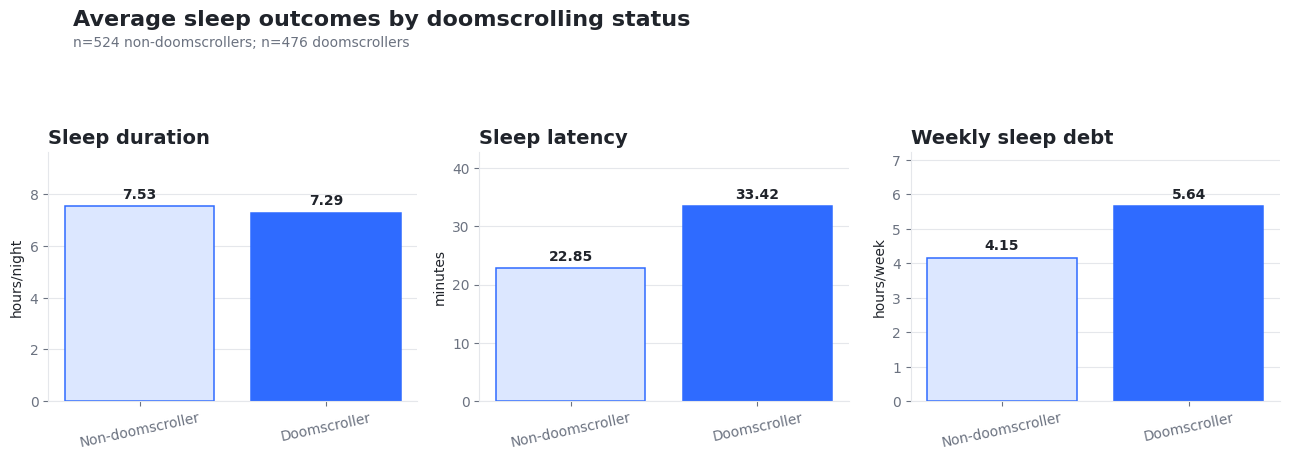

In [6]:
# 6. Visualize cohort sleep outcomes
metrics = [
    ("sleep_hours", "Sleep duration", "hours/night"),
    ("sleep_latency_minutes", "Sleep latency", "minutes"),
    ("weekly_sleep_debt_hours", "Weekly sleep debt", "hours/week"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
colors = [PALE_BLUE, BLUE]

for ax, (column, title, unit) in zip(axes, metrics):
    values = doom_summary[column]
    bars = ax.bar(["Non-doomscroller", "Doomscroller"], values, color=colors, edgecolor=BLUE, linewidth=1.1)
    ax.set_title(title, loc="left")
    ax.set_ylabel(unit)
    ax.set_ylim(0, values.max() * 1.28)
    ax.grid(axis="y")
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=12)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, value + values.max()*0.04, f"{value:.2f}", ha="center", fontweight="bold")

fig.suptitle("Average sleep outcomes by doomscrolling status", x=0.06, y=0.99, ha="left", fontsize=16, fontweight="bold")
fig.text(0.06, 0.91, "n=524 non-doomscrollers; n=476 doomscrollers", color=GREY)
plt.tight_layout(rect=[0, 0, 1, 0.84])
plt.show()


### 2. Poor sleep quality coincides with more bedtime screen time

Respondents in the poor sleep-quality category average nearly twice the bedtime screen time of respondents in the good category. The categories are balanced enough for a direct comparison (330 poor, 330 fair, 340 good).


,respondents,sleep_hours,bedtime_screen_minutes,phone_checks,stress_score,daytime_fatigue,exercise_minutes
sleep_quality_category,,,,,,,
Poor,330,6.97,69.74,3.20,6.41,6.58,50.46
Fair,330,7.51,46.12,2.34,6.05,5.80,52.83
Good,340,7.76,34.94,1.91,5.99,5.57,56.44


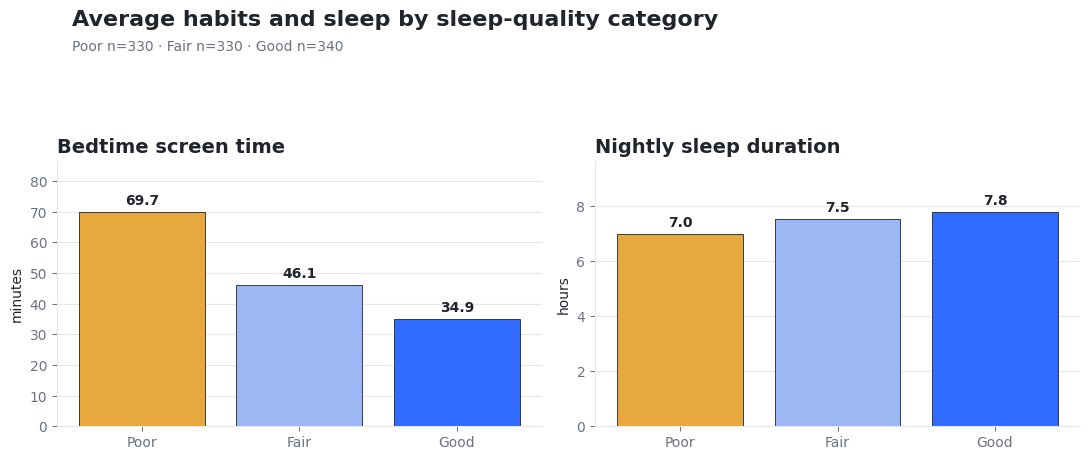

In [7]:
# 7. Compare sleep-quality categories
quality_order = ["Poor", "Fair", "Good"]
quality_summary = (
    df.groupby("sleep_quality_category", observed=True)
    .agg(
        respondents=("respondent_id", "count"),
        sleep_hours=("sleep_hours_per_night", "mean"),
        bedtime_screen_minutes=("bedtime_screen_time_minutes", "mean"),
        phone_checks=("phone_checks_per_night", "mean"),
        stress_score=("stress_score", "mean"),
        daytime_fatigue=("daytime_fatigue_score", "mean"),
        exercise_minutes=("exercise_minutes_per_day", "mean"),
    )
    .reindex(quality_order)
)
display(quality_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
palette = [GOLD, "#9DB7F5", BLUE]

for ax, column, title, unit in [
    (axes[0], "bedtime_screen_minutes", "Bedtime screen time", "minutes"),
    (axes[1], "sleep_hours", "Nightly sleep duration", "hours"),
]:
    values = quality_summary[column]
    bars = ax.bar(quality_order, values, color=palette, edgecolor=INK, linewidth=0.6)
    ax.set_title(title, loc="left")
    ax.set_ylabel(unit)
    ax.set_ylim(0, values.max() * 1.24)
    ax.grid(axis="y")
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, value + values.max()*0.035, f"{value:.1f}", ha="center", fontweight="bold")

fig.suptitle("Average habits and sleep by sleep-quality category", x=0.07, y=0.99, ha="left", fontsize=16, fontweight="bold")
fig.text(0.07, 0.90, "Poor n=330 · Fair n=330 · Good n=340", color=GREY)
plt.tight_layout(rect=[0, 0, 1, 0.82])
plt.show()


### 3. Bedtime screen time is the clearest non-derived correlate of sleep duration

Weekly sleep debt is mechanically related to insufficient sleep, so it is shown in the correlation table but not promoted as an independent behavioural driver. Bedtime screen time provides the strongest non-derived negative relationship with nightly sleep hours in this dataset.


,correlation_with_sleep_hours
weekly_sleep_debt_hours,-0.89
bedtime_screen_time_minutes,-0.44
doomscroll_sessions_per_night,-0.35
sleep_latency_minutes,-0.33
total_daily_screen_time_hours,-0.25
daytime_fatigue_score,-0.19
number_of_night_wakeups,-0.18
anxiety_score,-0.17
number_of_news_apps_used,-0.02
caffeine_intake_mg_per_day,0.03


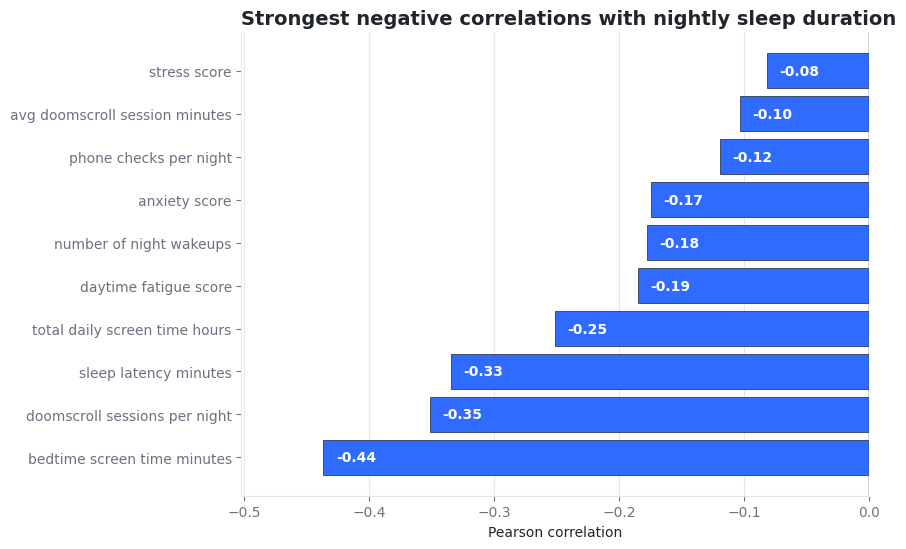

In [8]:
# 8. Rank correlations with nightly sleep duration
numeric_df = df.select_dtypes(include=np.number)
sleep_correlations = (
    numeric_df.corr()["sleep_hours_per_night"]
    .drop("sleep_hours_per_night")
    .sort_values()
)

selected_correlations = pd.concat([sleep_correlations.head(8), sleep_correlations.tail(5)]).drop_duplicates()
display(selected_correlations.rename("correlation_with_sleep_hours").to_frame())

plot_corr = sleep_correlations.drop("weekly_sleep_debt_hours").sort_values().head(10)
fig, ax = plt.subplots(figsize=(9, 5.6))
bars = ax.barh(plot_corr.index.str.replace("_", " "), plot_corr.values, color=BLUE, edgecolor=INK, linewidth=0.5)
ax.axvline(0, color=INK, linewidth=1)
ax.set_title("Strongest negative correlations with nightly sleep duration", loc="left")
ax.set_xlabel("Pearson correlation")
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(plot_corr.min() * 1.15, 0)
for bar, value in zip(bars, plot_corr.values):
    ax.text(value + 0.01, bar.get_y() + bar.get_height()/2, f"{value:.2f}", va="center", ha="left", color="white", fontweight="bold")
plt.tight_layout()
plt.show()


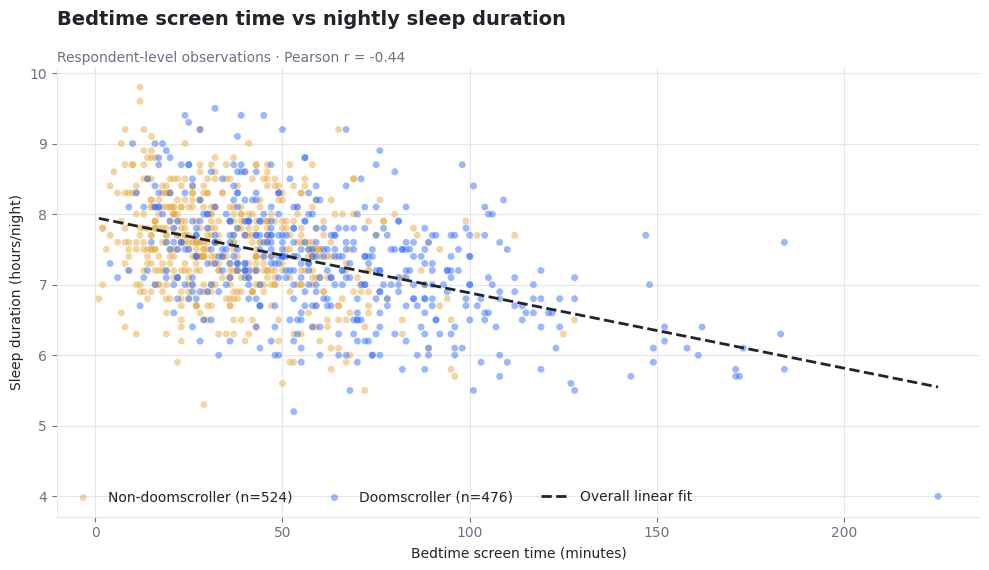

In [9]:
# 9. Inspect the screen-time/sleep relationship at respondent grain
fig, ax = plt.subplots(figsize=(10, 5.8))

for label, color in [("No", GOLD), ("Yes", BLUE)]:
    group = df[df["doomscroller"].eq(label)]
    ax.scatter(
        group["bedtime_screen_time_minutes"],
        group["sleep_hours_per_night"],
        s=25,
        alpha=0.48,
        color=color,
        edgecolor="none",
        label=f"{'Doomscroller' if label == 'Yes' else 'Non-doomscroller'} (n={len(group)})",
    )

x = df["bedtime_screen_time_minutes"].to_numpy()
y = df["sleep_hours_per_night"].to_numpy()
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope*x_line + intercept, color=INK, linewidth=2, linestyle="--", label="Overall linear fit")

ax.set_title("Bedtime screen time vs nightly sleep duration", loc="left", pad=30)
ax.text(0, 1.01, f"Respondent-level observations · Pearson r = {np.corrcoef(x, y)[0,1]:.2f}", transform=ax.transAxes, color=GREY)
ax.set_xlabel("Bedtime screen time (minutes)")
ax.set_ylabel("Sleep duration (hours/night)")
ax.grid(True)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=3, loc="lower left")
plt.tight_layout()
plt.show()


### 4. A leakage-controlled predictive benchmark

The model predicts `sleep_quality_category` using a 75/25 stratified split. Preprocessing is learned from the training data only. The following fields are excluded:

- `respondent_id` — identifier, not a feature.
- `sleep_quality_score` — likely a direct source of the category label.
- `weekly_sleep_debt_hours` — strongly derived from sleep duration.
- `doomscroller` — likely derived from the behavioural features already present.

Feature importance indicates predictive contribution, **not causal importance**.


In [10]:
# 10. Build a preprocessing and modelling pipeline
model_df = df.dropna(subset=["sleep_quality_category"]).copy()
y = model_df.pop("sleep_quality_category")

excluded_features = [
    "respondent_id", "sleep_quality_score", "weekly_sleep_debt_hours", "doomscroller"
]
X = model_df.drop(columns=excluded_features)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median"), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), categorical_features),
])

classifier = RandomForestClassifier(
    n_estimators=350,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

model = Pipeline([("preprocess", preprocessor), ("classifier", classifier)])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
baseline_accuracy = y_test.value_counts(normalize=True).max()

pd.DataFrame({
    "metric": ["Random forest accuracy", "Majority-class baseline", "Absolute improvement"],
    "value": [accuracy, baseline_accuracy, accuracy - baseline_accuracy],
}).style.format({"value": "{:.1%}"})


,metric,value
0,Random forest accuracy,58.0%
1,Majority-class baseline,34.0%
2,Absolute improvement,24.0%


,precision,recall,f1-score,support
Poor,0.64,0.66,0.65,82.00
Fair,0.45,0.35,0.40,83.00
Good,0.61,0.73,0.67,85.00
accuracy,0.58,0.58,0.58,0.58
macro avg,0.57,0.58,0.57,250.00


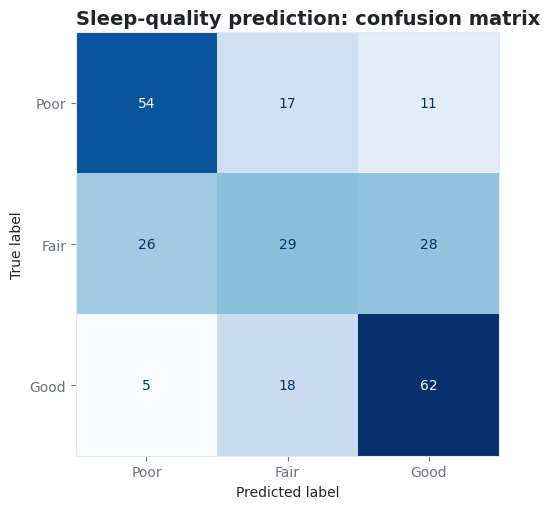

In [11]:
# 11. Review class-level performance and confusion matrix
report = pd.DataFrame(classification_report(y_test, predictions, output_dict=True)).T
display(report.loc[["Poor", "Fair", "Good", "accuracy", "macro avg"]].round(3))

fig, ax = plt.subplots(figsize=(6.5, 5.2))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    labels=["Poor", "Fair", "Good"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Sleep-quality prediction: confusion matrix", loc="left")
plt.tight_layout()
plt.show()


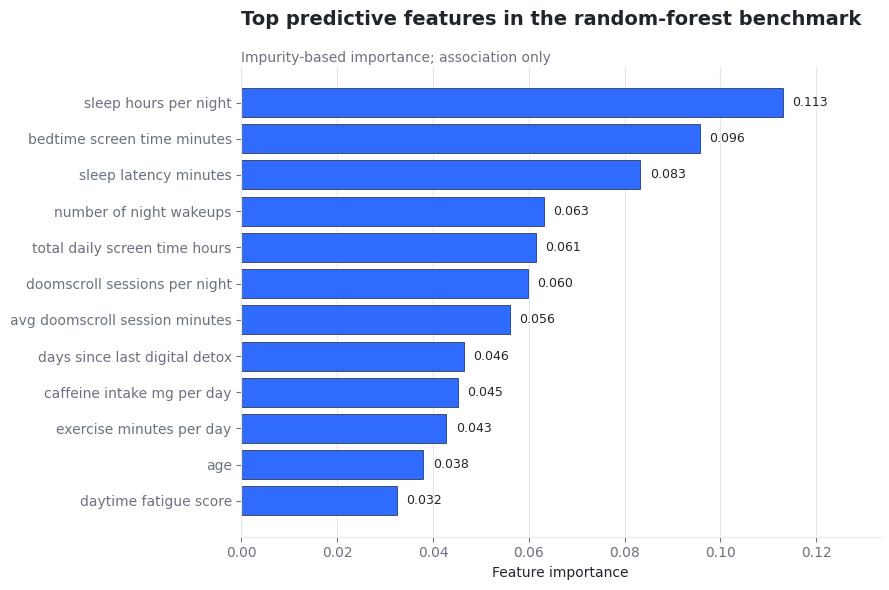

In [12]:
# 12. Rank model feature importance
feature_names = model.named_steps["preprocess"].get_feature_names_out()
feature_names = pd.Index(feature_names).str.replace(r"^(numeric|categorical)__", "", regex=True)
feature_importance = (
    pd.Series(model.named_steps["classifier"].feature_importances_, index=feature_names)
    .sort_values(ascending=False)
    .head(12)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(feature_importance.index.str.replace("_", " "), feature_importance.values, color=BLUE, edgecolor=INK, linewidth=0.5)
ax.set_title("Top predictive features in the random-forest benchmark", loc="left", pad=30)
ax.text(0, 1.01, "Impurity-based importance; association only", transform=ax.transAxes, color=GREY)
ax.set_xlabel("Feature importance")
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
for bar, value in zip(bars, feature_importance.values):
    ax.text(value + 0.002, bar.get_y() + bar.get_height()/2, f"{value:.3f}", va="center", fontsize=9)
ax.set_xlim(0, feature_importance.max() * 1.18)
plt.tight_layout()
plt.show()


## Takeaways

1. **The doomscrolling segment is large:** 476 of 1,000 respondents are labelled doomscrollers.
2. **Sleep latency is the clearest cohort gap:** doomscrollers take about 10.6 minutes longer to fall asleep on average.
3. **Sleep quantity and debt move in the expected direction:** doomscrollers average 0.24 fewer hours per night and 1.49 more weekly sleep-debt hours.
4. **Bedtime exposure matters more than total screen time in this sample:** bedtime screen time correlates with sleep duration at -0.44, compared with -0.25 for total daily screen time.
5. **Predictive signal exists, but the problem remains difficult:** the model reaches 58.0% accuracy versus a 34.0% baseline, and performs weakest on the middle `Fair` class.

### Limitations

- Observational, self-reported behavioural data cannot establish causality.
- Sampling method, field definitions, survey period, and representativeness were not provided.
- Several fields have 2–5% missingness; descriptive comparisons use available cases.
- The model is a portfolio benchmark, not a diagnostic or clinical tool.
- Importance scores can split or dilute signal across correlated predictors.

### Next steps

- Obtain a data dictionary and sampling documentation.
- Add confidence intervals or bootstrap uncertainty for cohort gaps.
- Test an ordinal model that respects `Poor < Fair < Good`.
- Validate findings on a separate sample or longitudinal dataset.
